In [1]:
import numpy as np
from astropy import units as u
from astropy import constants
import matplotlib.pyplot as plt
import pyccl as ccl
from scipy.integrate import simpson
import cosmopower as cp

2026-06-05 16:16:32.627801: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
### Define the cosmological parameters that are used for the training of the emulator.
cosmology = [0.3089,0.0486,0.8159,0.6774]
Om=cosmology[0]
Ob=cosmology[1]
s8=cosmology[2]
ns=0.9967
h0=cosmology[3]

m2 = 1/u.m/u.m
cosmo = ccl.Cosmology(Omega_c=Om-Ob, Omega_b=Ob, h=h0, sigma8=s8, n_s=ns)
H0 = h0 * 100 * u.km / u.s / u.Mpc 
prefac = 3.0*constants.c.value / \
(constants.m_p.value*constants.G.value*8.0*np.pi) * \
(H0.to(1/u.s)).value * \
m2.to(u.parsec/u.cm**3).value*Ob

### Define the functions to calculate the mean DM as a function of redshift.
### Don't touch these!
def weight(z):
    f_IGM = 0.9  # keep constant for now at redshifts < 1. Can be calculated from https://github.com/FRBs/FRB/blob/main/frb/dm/igm.py as f_diffuse
    f_He = 0.24  # Helium fraction
    f_H = 1. - f_He
    f_e = (f_H + 1/2. * f_He)  # electron fraction
    result = f_e * f_IGM * prefac*(1+z)/ccl.h_over_h0(cosmo,1/(1+z))
    return result
def mean(z):
    zval = np.linspace(0,z,1000)
    integrand = weight(zval)
    integral = simpson(integrand,x=zval)
    return integral


Call the emulator!

In [7]:
cp_nn = cp.cosmopower_PCAplusNN(restore=True,restore_filename='./DMpdf_emu')


The emulator is valid in the following parameter ranges:

eta    (0, 0.5) 

deta   (0, 0.5)

Nstar  (0, 0.05)

ciga   (0, 1)

thco   (0.001, 0.5)

Mc     (11, 15)

mu     (0, 2)

delta  (4, 11)

z_frb  (0.3, 5)

In [8]:
### Define the parameters for the emulator
### eta, deta, Nstar, ciga, theta_core, log10(Mc), mu, delta, redshift
params = [ 0.46046443,  0.05566517,  0.04994884,  0.14085006,  0.48839608, 12.47039461,
  1.1084508,   7.98880269,2]


In [9]:

test_parameters = { 'z_frb': [params[8]],
                'eta': [params[0]],
                'deta': [params[1]],
                'Nstar': [params[2]],
                'ciga': [params[3]],
                'thco': [params[4]],
                'Mc': [params[5]],
                'mu': [params[6]],
                'delta': [params[7]],    }

predicted_testing_spectra = cp_nn.predictions_np(test_parameters)
pred = predicted_testing_spectra[0] -1 ### note that the emulator predicts the PDF+1, so we need to subtract 1 to get the PDF.
z = test_parameters['z_frb']
dom = np.linspace(0.0001,2,1000)

DM = dom*mean(z[0])
norm = simpson(pred,x=DM)


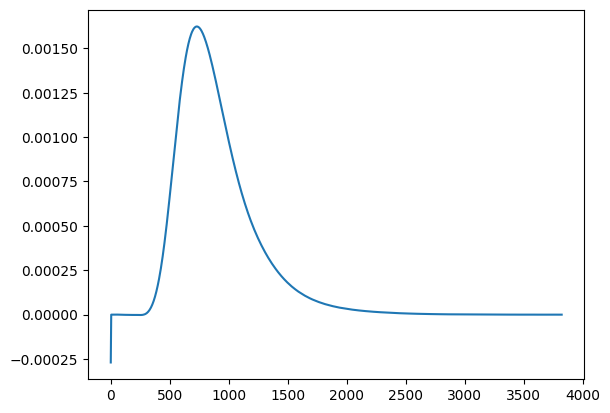

In [10]:
plt.plot(DM,pred/norm)